In [3]:
!pip install lime shap

In [1]:
import numpy as np
import pandas as pd

📄 STEP 3: Load Dataset

In [ ]:
from google.colab import files
files.upload()   # upload data.csv

Saving data.csv to data.csv


{'data.csv': b'"id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean","radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave points_se","symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst",\r\n842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189\r\n842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902\r\n84300903,M,1

In [ ]:

df = pd.read_csv("/content/data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


🔍 STEP 4: Data Understanding

In [ ]:
print("Shape:", df.shape)

Shape: (569, 33)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


STEP 5: Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Drop unnecessary columns
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Convert target (M = 0, B = 1)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

# Split features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

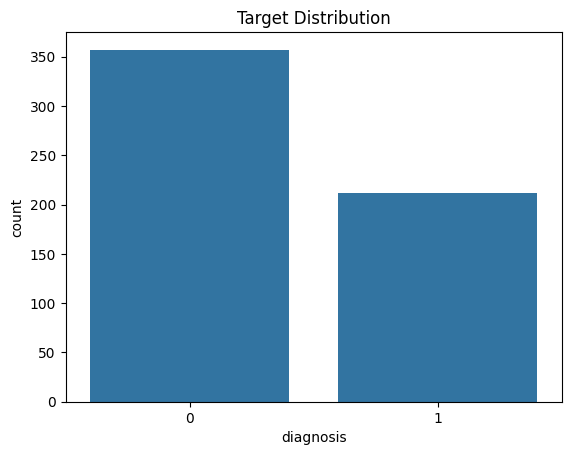

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check distribution
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

Correlation

In [ ]:
# show only top correlated features
corr = df.corr()['diagnosis'].abs().sort_values(ascending=False)
print(corr.head(10))

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
Name: diagnosis, dtype: float64


🔹 Train-Test Split + Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 STEP 6: Train ML Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [ ]:
lr = LogisticRegression(max_iter=5000)
svm = SVC(probability=True, kernel='linear') # Added kernel='linear'
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
lr.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

STEP 7: Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf
}

for name, model in models.items():
    if name == "Random Forest":
        preds = model.predict(X_test)
    else:
        preds = model.predict(X_test_scaled)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


Logistic Regression
Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


SVM
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Random Forest
Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
 

Confusion Matrix (Better Visualization)

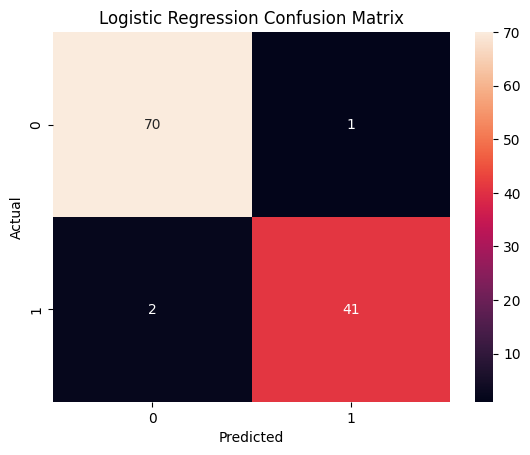

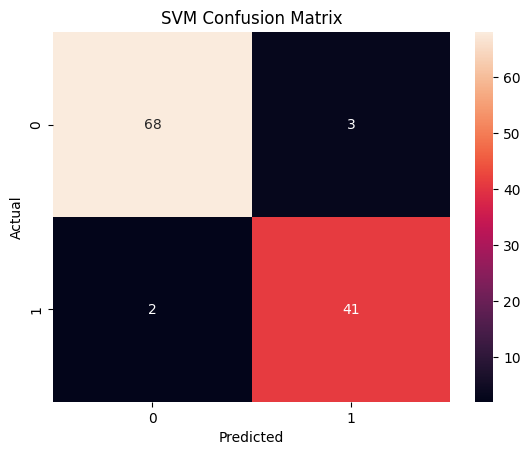

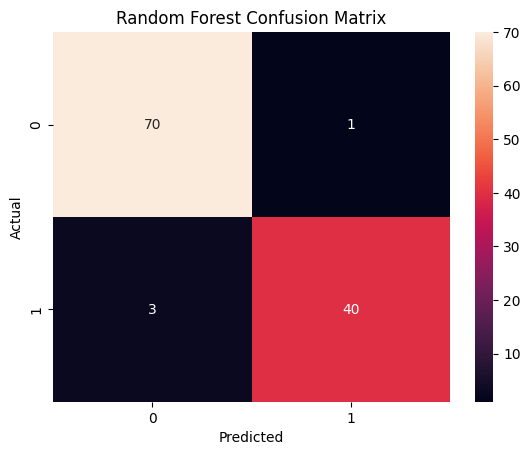

In [ ]:
for name, model in models.items():
    if name == "Random Forest":
        preds = model.predict(X_test)
    else:
        preds = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, preds)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

STEP 8: Feature Importance (Random Forest)

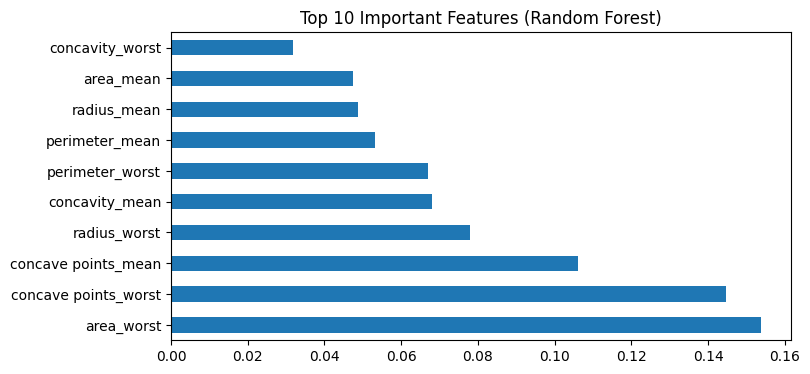

In [ ]:
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_importance = rf_importance.sort_values(ascending=False)

plt.figure(figsize=(8,4))
rf_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

In [ ]:
top_features = rf_importance.head(10).index.tolist()

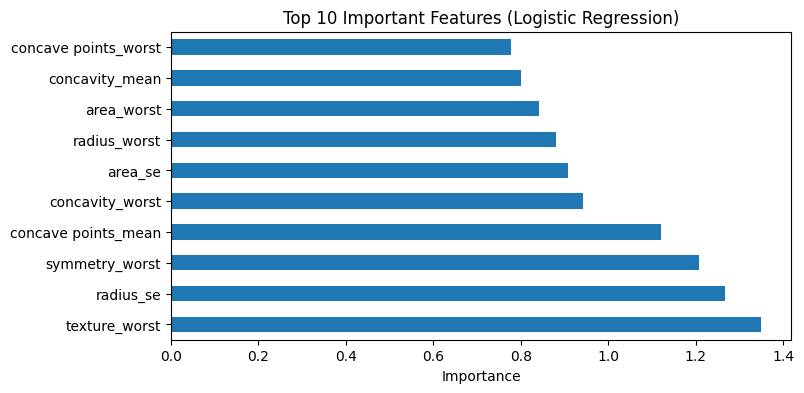

In [ ]:
lr_importance = pd.Series(lr.coef_[0], index=X.columns)
lr_importance = lr_importance.abs().sort_values(ascending=False)

# Plot top 10
plt.figure(figsize=(8,4))
lr_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features (Logistic Regression)")
plt.xlabel("Importance")
plt.show()

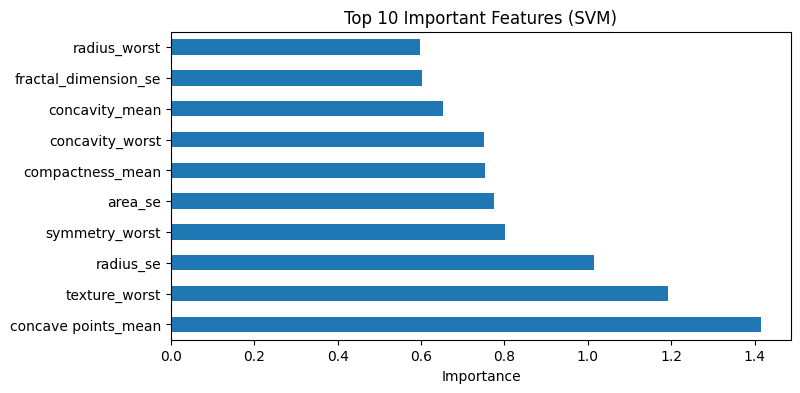

In [ ]:
# Get coefficients
svm_importance = pd.Series(svm.coef_[0], index=X.columns)

# Absolute values
svm_importance = svm_importance.abs().sort_values(ascending=False)

# Plot top 10
plt.figure(figsize=(8,4))
svm_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features (SVM)")
plt.xlabel("Importance")
plt.show()

In [ ]:
heatmap_data = df[top_features + ['diagnosis']]

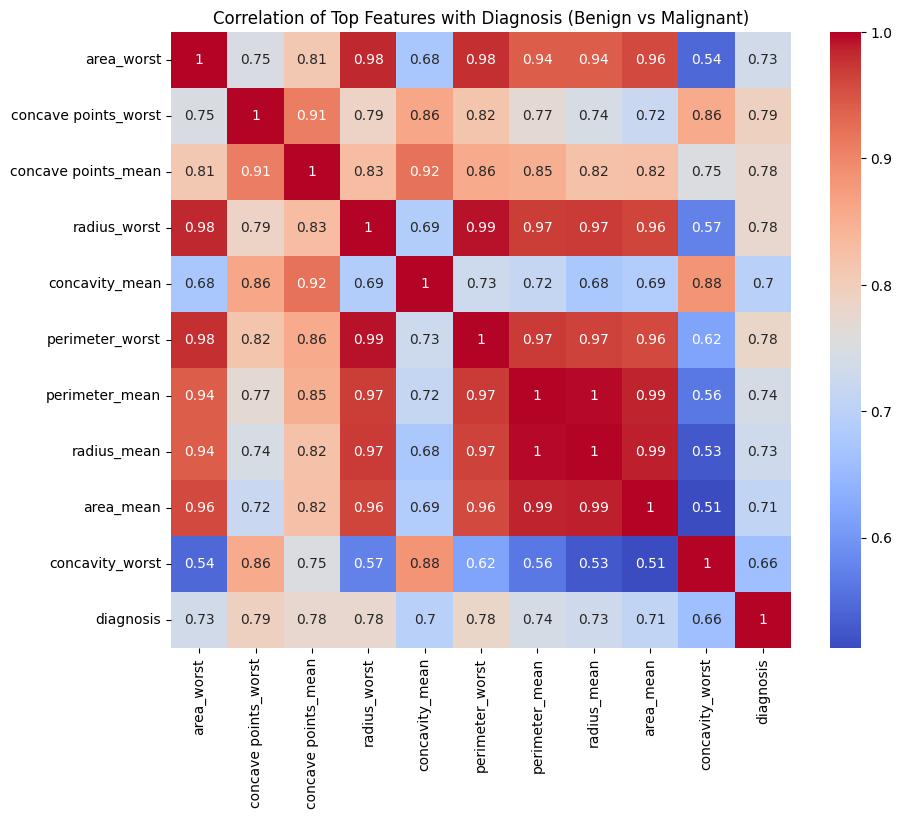

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation of Top Features with Diagnosis (Benign vs Malignant)")
plt.show()

STEP 9: SHAP (Global Explanation)

In [ ]:
import shap

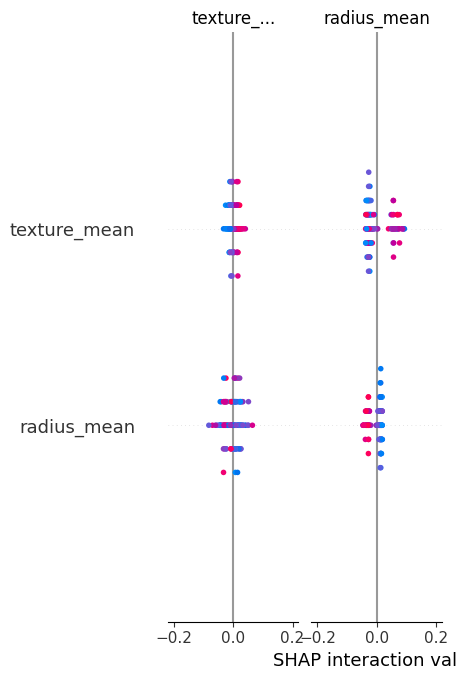

In [ ]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

🔍 STEP 10: LIME (Local Explanation)

In [ ]:
import lime
import lime.lime_tabular

In [ ]:
# Initialize LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values, # Use unscaled training data for Random Forest
    feature_names=X.columns.tolist(),
    class_names=['Malignant', 'Benign'], # Order based on rf.predict_proba output
    mode='classification'
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


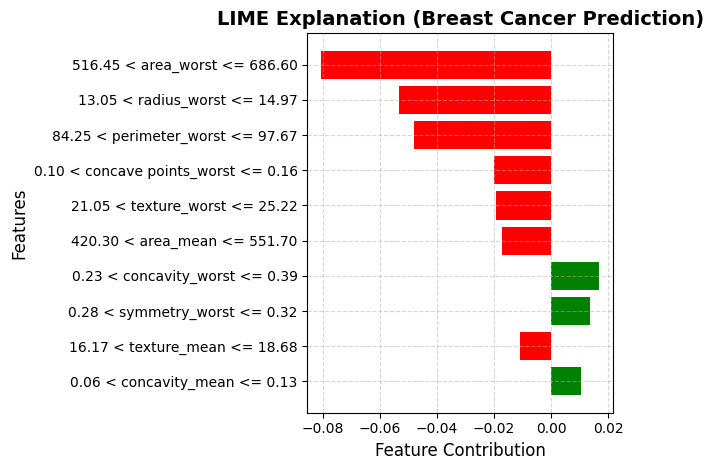

In [ ]:
# Generate explanation
fig = explainer.as_pyplot_figure()

# Customize appearance
plt.title("LIME Explanation (Breast Cancer Prediction)", fontsize=14, weight='bold')
plt.xlabel("Feature Contribution", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Improve layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [ ]:
probs = rf.predict_proba(X_test.iloc[[0]])[0]

print(f"Malignant: {probs[0]:.2f}")
print(f"Benign: {probs[1]:.2f}")

Malignant: 0.97
Benign: 0.03


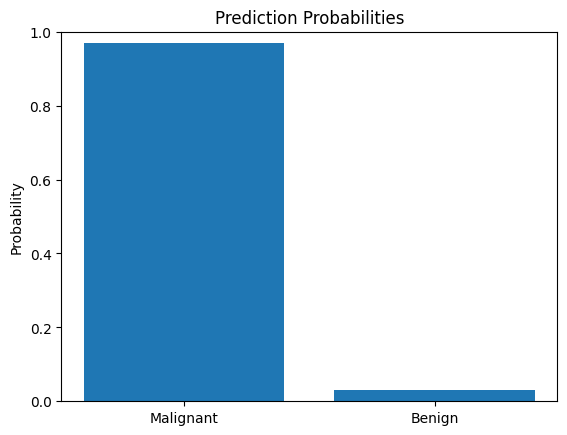

In [ ]:
import numpy as np

probs = rf.predict_proba(X_test.iloc[[0]])[0]
labels = ["Malignant", "Benign"]

plt.figure()
plt.bar(labels, probs)
plt.title("Prediction Probabilities")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.show()

STEP 11: Feature Comparison Across Models

In [ ]:
explainer_svm = shap.KernelExplainer(
    svm.predict_proba,
    X_train_scaled[:100]   # small sample for speed
)

In [ ]:
shap_values_svm = explainer_svm.shap_values(X_test_scaled[:50])

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
print(type(shap_values_svm))
print(len(shap_values_svm))
print(np.array(shap_values_svm).shape)

<class 'numpy.ndarray'>
50
(50, 30, 2)


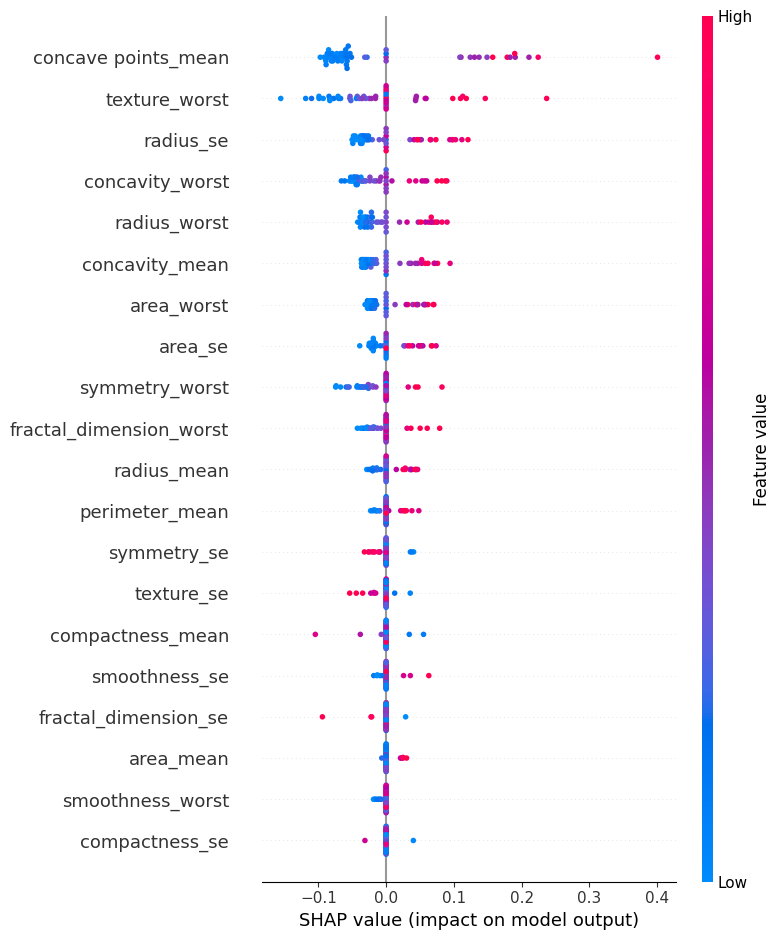

In [ ]:

svm_shap = shap_values_svm[:, :, 1]

# Correct plot
shap.summary_plot(
    svm_shap,
    X_test_scaled[:50],
    feature_names=X.columns
)

In [ ]:
svm_importance = np.abs(svm_shap).mean(axis=0)

svm_importance = pd.Series(svm_importance, index=X.columns)
svm_importance = svm_importance.sort_values(ascending=False)

print(svm_importance.head(10))

concave points_mean        0.094172
texture_worst              0.055595
radius_se                  0.040968
concavity_worst            0.037176
radius_worst               0.034281
concavity_mean             0.031458
area_worst                 0.026488
area_se                    0.022299
symmetry_worst             0.022125
fractal_dimension_worst    0.014808
dtype: float64


In [ ]:
# Logistic Regression importance
lr_importance = pd.Series(
    np.abs(lr.coef_[0]), index=X.columns).sort_values(ascending=False)

print("\nTop Features (Logistic Regression):")
print(lr_importance.head(10))

# Common features
common_features = set(rf_importance.head(10).index) & set(lr_importance.head(10).index)

print("\nCommon Important Features Across Models:")
print(common_features)


Top Features (Logistic Regression):
texture_worst           1.350606
radius_se               1.268178
symmetry_worst          1.208200
concave points_mean     1.119804
concavity_worst         0.943053
area_se                 0.907186
radius_worst            0.879840
area_worst              0.841846
concavity_mean          0.801458
concave points_worst    0.778217
dtype: float64

Common Important Features Across Models:
{'radius_worst', 'concave points_mean', 'area_worst', 'concavity_mean', 'concavity_worst', 'concave points_worst'}


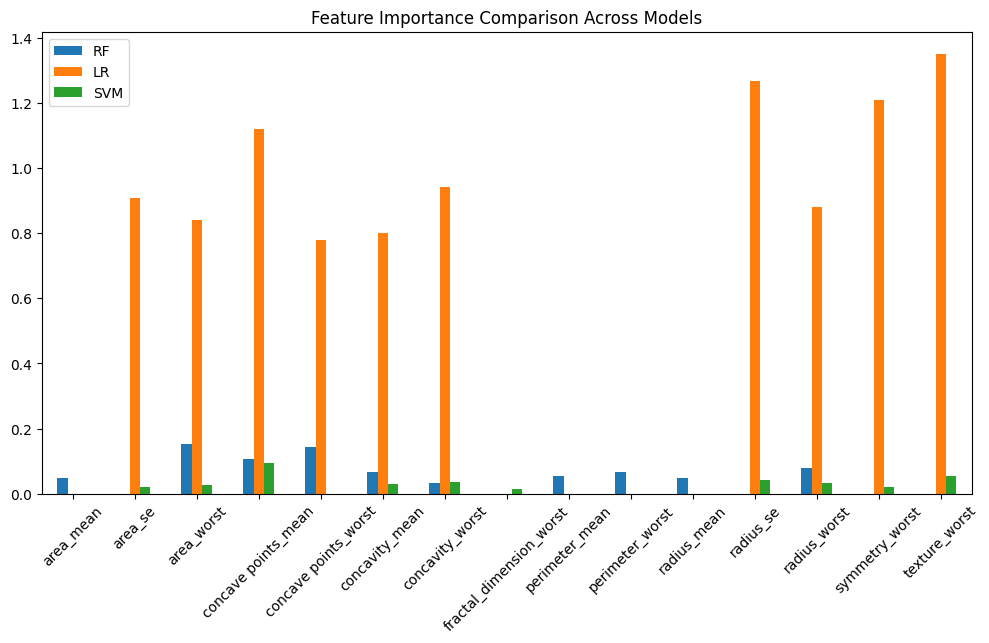

In [ ]:
common_df = pd.DataFrame({
    'RF': rf_importance.head(10),
    'LR': lr_importance.head(10),
    'SVM': svm_importance.head(10)
}).fillna(0)

common_df.plot(kind='bar', figsize=(12,6))
plt.title("Feature Importance Comparison Across Models")
plt.xticks(rotation=45)
plt.show()